In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 7.8 The Classical Limit and the Thermal Wavelength: The N! Derived

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VII — Quantum Statistical Mechanics",
    number="7.8",
    title="The Classical Limit and the Thermal Wavelength: The N! Derived",
    blurb="One length decides everything. The thermal de Broglie wavelength is the size of "
    "a particle's wavepacket, and quantum statistics is what happens when wavepackets "
    "touch: one dimensionless number sorts air from copper from superfluid helium. In "
    "the dilute limit the Gibbs N!, inserted by hand in Volume V, simply falls out "
    "of the bookkeeping, the measured entropy of room-temperature argon turns out to "
    "contain Planck's constant, and the first whisper of statistics appears as a "
    "pressure shift: an attraction between bosons and a repulsion between fermions, "
    "with no force anywhere in sight.",
    difficulty="advanced",
    estimate="185–225 min",
)

<ECP header: 2949 chars of HTML>

## Notebook overview

Movement II's first notebook derived the quantum distributions; this one asks where the classical
world lives, and answers with a single length. In the dilute limit $z \ll 1$ both of the gases of [§7.7](bose-einstein-fermi-dirac.ipynb)
collapse onto $\ln\Xi = zZ_1$, and the single-particle sum evaluates to $Z_1 = V/\lambda_T^3$ with

$$
\lambda_T = \frac{h}{\sqrt{2\pi m k_B T}},
$$

the **thermal de Broglie wavelength** — the size of a particle's thermal wavepacket. Quantum
statistics matters when wavepackets *overlap*, and the criterion $n\lambda_T^3 \sim 1$ turns out
to be the volume's road map: one dimensionless number, computed honestly in SI for five systems,
sorts air (never quantum, $10^{-7}$) from copper's electrons (never classical, $10^{3}$ — the
mandate of Movement III, which begins next door) from liquid helium at its lambda point (just past
the condensation threshold, and superfluid on schedule) from an engineered ultracold cloud from
the Boltzmann-licensed carriers of a semiconductor (the permission slip of [§7.13](semiconductor-statistics.ipynb)).

The centerpiece completes an arc the volume has been building for three notebooks. Expanding
$\Xi = e^{zZ_1}$ and reading off the canonical $Z_N = Z_1^N/N!$, the **Gibbs factor falls out** —
not bolted on to fix a paradox, but inevitable, because occupation-number states never carried
particle labels in the first place ([§6.20](../06-quantum-mechanics/identical-particles.ipynb) answering the question [§5.1](../05-classical-stat-mech/counting.ipynb)/[§5.6](../05-classical-stat-mech/ideal-gas-fundamental-relation.ipynb) raised). With it comes
**Sackur–Tetrode**, and the notebook's jewel: argon's standard molar entropy, computed from
$h$, $k_B$, and a mass, reproduces the *measured* $154.85$ J mol⁻¹K⁻¹ to every displayed digit —
a room-temperature calorimetric number that contains Planck's constant. The arc of derived conventions is
complete: $h$ ([§7.5](oscillator-at-temperature.ipynb)), $\sigma$ ([§7.6](molecules-rotation-vibration.ipynb)), $N!$ (here).

The rest of the notebook measures what "almost classical" means. In the equation of state, the
exact quantum EOS (the polylogarithms of [§7.3](statistical-toolkit.ipynb)) yields the **pure-statistics virial** $PV/Nk_BT = 1 \mp
n\lambda^3/2^{5/2}$: bosons *reduce* the pressure and fermions *raise* it, an attraction and a
repulsion with no force anywhere — bunching's thermodynamic face, and the embryo of the degeneracy
pressure that opens [§7.9](fermi-gas-zero-temperature.ipynb). And in real space, the one-body density matrix is verified to be a
Gaussian of width exactly $\lambda_T$ (the wavepacket is not a metaphor: $\lambda_T$ is the
coherence length), so the dilute pair correlation $g(r) = 1 \pm e^{-2\pi r^2/\lambda_T^2}$ carries
the exchange effects at range $\lambda_T$: a bunching peak $g(0) = 2$ for bosons, an **exchange
hole** $g(0) = 0$ for fermions. An exact two-particle computation in a box certifies both
honestly — the fermionic coincidence amplitude vanishes identically at any size (antisymmetry
needs no thermodynamic limit), while the bosonic enhancement reads $1.77$ at $N = 2$ and trends
to the ideal $2$, with the finite-size sources named rather than hidden.

> **Conventions (this notebook).** Structural checks run in working units $\hbar = m = k_B = 1$
> (where $\lambda_T = \sqrt{2\pi\beta}$); everything that touches a real substance — the
> degeneracy table, Sackur–Tetrode — runs in full SI with CODATA constants in Setup.
> The virial slopes are extracted at *small* fugacity ($z \le 0.05$) and shown converging, with
> one deliberately contaminated fit at large $z$ for contrast. Truncations and mode counts are
> stated; the two-particle box sums keep the $n = m$ diagonal for bosons and exclude it for
> fermions — the off-by-one that silently breaks both answers.
>
> **How to read the checks.** Each exercise closes with a `validate` call against an independent
> fact: $Z_1 = V/\lambda_T^3$ against the density-of-states integral to eight digits; the
> degeneracy table against its verified values across eleven decades; zero mixing entropy with
> the $N!$ (and $2Nk_B\ln2$ without); argon's $154.85$ against the third-law calorimetric value;
> the virial slopes converging to $\mp1/2^{5/2}$; the $\rho_1$ Gaussian to six digits; and the
> exact box certification of the exchange hole and the bunching factor. A ✓ is strong evidence;
> a ✗ is a prompt to *locate the discrepancy*.
>
> **Scope.** The classical boundary of the quantum gases, and the fingerprints that survive
> inside it. Degeneracy pressure grown up is [§7.9](fermi-gas-zero-temperature.ipynb); the banded solids are [§7.12](bloch-theorem-band-structure.ipynb)/[§7.13](semiconductor-statistics.ipynb); $\mu = 0$
> light is [§7.14](photon-gas-planck.ipynb); the criterion becoming a phase boundary ($n\lambda^3 = \zeta(3/2)$) is [§7.17](bose-einstein-condensation.ipynb); the
> ring polymer whose size is this notebook's $\lambda_T$ is [§7.20](imaginary-time-quantum-classical.ipynb)/[§7.21](path-integral-monte-carlo.ipynb). See Pathria & Beale
> (Chs. 5–7); Kardar, *Statistical Physics of Particles* (Ch. 7); Kittel & Kroemer (the
> Sackur–Tetrode test); Huang (the quantum virial). Cross-reference [§5.1](../05-classical-stat-mech/counting.ipynb)/[§5.6](../05-classical-stat-mech/ideal-gas-fundamental-relation.ipynb) (the counting and the
> inserted $N!$), [§5.3](../05-classical-stat-mech/large-n-limit.ipynb) (Stirling), [§6.20](../06-quantum-mechanics/identical-particles.ipynb) (indistinguishability, put to work), [§7.3](statistical-toolkit.ipynb) (the DOS and
> polylogarithms), [§7.5](oscillator-at-temperature.ipynb)/[§7.6](molecules-rotation-vibration.ipynb) (the arc's first entries), [§7.7](bose-einstein-fermi-dirac.ipynb) (the distributions).

## Theory in brief

### The dilute limit and the thermal wavelength

Start from the exact expression of [§7.7](bose-einstein-fermi-dirac.ipynb), $\ln\Xi = \mp\sum_i\ln(1 \mp ze^{-\beta\varepsilon_i})$ and let $z \ll 1$:
the logarithms linearize and both statistics collapse onto $\ln\Xi \to z\sum_i e^{-\beta
\varepsilon_i} = zZ_1$. The single-particle sum is a Gaussian momentum integral (the density of
states of [§7.3](statistical-toolkit.ipynb) doing the counting):

```{math}
:label: eq-thermal-wavelength
Z_1 = V\int\frac{d^3k}{(2\pi)^3}\,e^{-\beta\hbar^2k^2/2m} = \frac{V}{\lambda_T^3},
\qquad
\lambda_T = \frac{h}{\sqrt{2\pi m k_B T}} .
```

$\lambda_T$ is the de Broglie wavelength of a particle carrying thermal momentum, with the honest
$\sqrt{2\pi}$ bookkeeping the Gaussian integral supplies — the *size of the thermal wavepacket*,
and Exercise 6 will show that reading is exact, not rhetorical. The scalings carry the physics:
$\lambda_T \propto 1/\sqrt{mT}$, so **light and cold is quantum**.

### The degeneracy criterion: one number sorts matter

Quantum statistics matters when wavepackets overlap — when the volume per particle is comparable
to the coherence volume:

```{math}
:label: eq-degeneracy-criterion
n\lambda_T^3 \sim 1
\qquad\text{(degenerate)},
\qquad
n\lambda_T^3 \ll 1
\qquad\text{(classical)}.
```

One table, computed in SI, sorts everything this volume will touch: air at $\sim10^{-7}$ (never
quantum); copper's conduction electrons at $\sim7\times10^{3}$ (never classical — the electron's
tiny mass, and Movement III's mandate); liquid helium-4 at its lambda point at $4.5$, just past
the condensation threshold $\zeta(3/2) = 2.612$ — superfluidity arriving where the *ideal-gas*
criterion says it should (an honest caveat: helium is strongly interacting, and the
semiquantitative agreement is the remarkable part); an ultracold rubidium cloud at $\sim21$
(degeneracy *engineered* — the laboratories of [§7.17](bose-einstein-condensation.ipynb)); and silicon's intrinsic carriers at
$\sim5\times10^{-9}$ (Boltzmann statistics licensed, which is exactly why the semiconductor
carriers of [§7.13](semiconductor-statistics.ipynb) may be treated classically until doping says otherwise).

### The N! falls out: Gibbs derived

In the dilute limit $\Xi = e^{zZ_1}$; expand and match against the definition $\Xi = \sum_N z^N
Z_N$:

```{math}
:label: eq-gibbs-derived
\Xi = e^{zZ_1} = \sum_{N=0}^{\infty}\frac{(zZ_1)^N}{N!}
\qquad\Longrightarrow\qquad
Z_N = \frac{Z_1^N}{N!} .
```

The Gibbs factor is *derived*, not imposed. Volume V had to divide by $N!$ by hand ([§5.6](../05-classical-stat-mech/ideal-gas-fundamental-relation.ipynb)) because
its phase-space integral counted each physical configuration $N!$ times, once per particle
labelling; occupation-number states ([§7.7](bose-einstein-fermi-dirac.ipynb)) never labelled particles, so the overcounting never
occurs and the factorial arrives already in place. The Gibbs paradox dissolves with it: without
the $N!$, entropy is non-extensive and "mixing" two samples of the *same* gas creates $2Nk_B\ln2$
of entropy from nothing; with it, zero, as it must. The arc closes: $h$ ([§7.5](oscillator-at-temperature.ipynb)), $\sigma$ ([§7.6](molecules-rotation-vibration.ipynb)),
$N!$ (here) — every fudge factor in the classical formalism was a quantum limit.

### Sackur–Tetrode against the laboratory

From $Z_N = (V/\lambda_T^3)^N/N!$, the free energy and Stirling ([§5.3](../05-classical-stat-mech/large-n-limit.ipynb)) give the absolute entropy of
a monatomic ideal gas,

```{math}
:label: eq-sackur-tetrode
\frac{S}{Nk_B} = \ln\!\frac{v}{\lambda_T^3} + \frac{5}{2},
\qquad
v = \frac{V}{N} = \frac{k_BT}{P},
```

extensive at last, and **absolute** — no undetermined constant, because $\lambda_T$ carries $h$.
The test against data is the notebook's jewel: argon at $298.15$ K and $1$ bar gives $154.85$
J mol⁻¹K⁻¹ against the *measured* standard molar entropy $154.85$ — a third-law calorimetric
number, assembled by integrating $C_p\,dT/T$ from near absolute zero through two phase
transitions, agreeing to every displayed digit with a formula containing $\hbar$. Classical
thermodynamics can only ever measure entropy *differences*; the absolute scale exists because
phase space is cellular, with cell size $h$ — Planck's constant, readable in a
nineteenth-century-style measurement.

### Statistics as pressure: the pure-statistics virial

The exact ideal quantum EOS, in the parametric form the functions of [§7.3](statistical-toolkit.ipynb) provide,

```{math}
:label: eq-statistics-virial
n\lambda^3 = \pm\mathrm{Li}_{3/2}(\pm z),
\qquad
\frac{P\lambda^3}{k_BT} = \pm\mathrm{Li}_{5/2}(\pm z),
\qquad\Longrightarrow\qquad
\frac{PV}{Nk_BT} = 1 \mp \frac{n\lambda^3}{2^{5/2}} + \mathcal{O}\big((n\lambda^3)^2\big),
```

with upper signs bosonic. The correction is a **second virial coefficient of pure statistics**,
$B_2 = \mp\lambda^3/2^{5/2}$: with no interaction anywhere, bosons exert *less* pressure than a
classical gas at the same density (a statistical attraction — bunching's thermodynamic face, and
the shadow of the condensation of [§7.17](bose-einstein-condensation.ipynb)) and fermions *more* (a statistical repulsion — the embryo of
the degeneracy pressure that will hold up white dwarfs in [§7.11](white-dwarfs-chandrasekhar.ipynb)). Exercise 5 extracts the
coefficient from the exact EOS and watches it converge to $\mp1/2^{5/2} = \mp0.17678$.

### Exchange in real space: the range of the statistical force

The one-body density matrix (the spatial coherence of a single thermal particle) is the Fourier
transform of the occupation:

```{math}
:label: eq-exchange-real-space
\frac{\rho_1(r)}{n} = e^{-\pi r^2/\lambda_T^2},
\qquad
g(r) = 1 \pm \left|\frac{\rho_1(r)}{n}\right|^2 = 1 \pm e^{-2\pi r^2/\lambda_T^2},
```

the first verified to six digits by the radial transform (a Gaussian of width *exactly*
$\lambda_T$: the coherence length, and the degeneracy criterion is literally "coherence volumes
overlapping"), the second the dilute pair correlation. Bosons **bunch**: $g(0) = 2$, the factor
of two of thermal light — the geometric variance of [§7.5](oscillator-at-temperature.ipynb) and the $n(1+n)$ of [§7.7](bose-einstein-fermi-dirac.ipynb), landed in real space
(Hanbury Brown–Twiss, by name). Fermions dig an **exchange hole**: $g(0) = 0$, Pauli in space,
ancestor of the exchange–correlation holes of electronic-structure theory (a horizon nodding
toward [§7.12](bloch-theorem-band-structure.ipynb) and the MMM course). An exact two-particle computation in a box certifies both: the
antisymmetrized coincidence amplitude vanishes *identically* — at any size, any temperature —
while the symmetrized enhancement reads $1.77$ at $N = 2$ and approaches the ideal $2$ only as
the box grows, the finite-size bookkeeping taught as such. The statistical "interaction" has a
range, and the range is $\lambda_T$.

### Where the movements go from here

The classical world is the regime $n\lambda^3 \ll 1$: too dilute, too heavy, too hot for
wavepackets to touch. Three roads leave it. **Dense and light** — electrons in metals and dead
stars — is Movement III, beginning immediately ([§7.9](fermi-gas-zero-temperature.ipynb)). **Cold** (helium and the engineered
condensates) is Movement IV ([§7.17](bose-einstein-condensation.ipynb)). **Massless** (light, for which $\mu = 0$ and no classical
regime ever existed) is the photon gas ([§7.14](photon-gas-planck.ipynb)). The criterion is the volume's road map.

## Setup

In [2]:
import matplotlib.pyplot as plt
import mpmath
import numpy as np
from scipy.integrate import quad
from scipy.special import zeta

from ecp import draw, validate

ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT
RED = "#c1121f"

# Conventions. Structural checks: working units ħ = m = k_B = 1, where
# λ_T = √(2πβ). Real substances: full SI, CODATA-2018 constants below, no premature
# rounding (the Sackur–Tetrode match to every displayed digit needs the digits).
# Truncations and mode counts stated at point of use; the two-particle box sums keep
# the n = m diagonal for bosons and exclude it for fermions.
H_PLANCK = 6.62607015e-34  # J s (exact, SI 2019)
K_B = 1.380649e-23  # J/K (exact)
N_AVOGADRO = 6.02214076e23  # 1/mol (exact)
R_GAS = N_AVOGADRO * K_B  # J/(mol K) = 8.31446...
U_AMU = 1.66053906660e-27  # kg
M_ELECTRON = 9.1093837015e-31  # kg


def lambda_T(m, T):
    """The thermal de Broglie wavelength λ_T = h/√(2π m k_B T) in SI (eq-thermal-wavelength).

    The size of a thermal wavepacket: the de Broglie wavelength at thermal momentum,
    with the √(2π) the Gaussian momentum integral supplies (not a convention — the
    factor that makes Z_1 = V/λ^3 exact). Scalings: ∝ 1/√(mT) — light and cold is
    quantum. All CODATA constants, no rounding.

    Parameters
    ----------
    m : float
        Particle mass in kg.
    T : float
        Temperature in K.

    Returns
    -------
    float
        λ_T in metres.
    """
    return H_PLANCK / np.sqrt(2.0 * np.pi * m * K_B * T)


def degeneracy(n, m, T):
    """The degeneracy parameter n λ_T^3 — the one number that sorts matter (eq-degeneracy-criterion).

    The number of particles per coherence volume: << 1 means wavepackets never touch
    (classical), ~ 1 means quantum statistics governs, with the Bose condensation
    threshold sitting at ζ(3/2) = 2.612 (§7.17). Exercise 2's table runs this across
    eleven decades of real matter.

    Parameters
    ----------
    n : float
        Number density in 1/m^3.
    m : float
        Particle mass in kg.
    T : float
        Temperature in K.

    Returns
    -------
    float
        The dimensionless n λ_T^3.
    """
    return n * lambda_T(m, T) ** 3


def sackur_tetrode(m, T, P):
    """The Sackur–Tetrode molar entropy S = R[ln(k_B T/(P λ_T^3)) + 5/2] (eq-sackur-tetrode).

    The absolute entropy of a monatomic ideal gas: extensive (the derived N! at work)
    and ℏ-bearing (the λ_T^3 cell in phase space). Precision note: the match to
    argon's measured 154.85 J/(mol K) is exact to the displayed digits only if the
    constants carry full CODATA precision end to end — premature rounding of λ_T
    moves the second decimal.

    Parameters
    ----------
    m : float
        Atomic mass in kg.
    T : float
        Temperature in K.
    P : float
        Pressure in Pa.

    Returns
    -------
    float
        Molar entropy in J/(mol K).
    """
    v = K_B * T / P  # volume per particle
    return R_GAS * (np.log(v / lambda_T(m, T) ** 3) + 2.5)


def quantum_eos(z, statistics):
    """The exact ideal quantum EOS, parametric in fugacity (eq-statistics-virial).

    Returns (nλ^3, Pλ^3/k_BT) = (±Li_(3/2)(±z), ±Li_(5/2)(±z)) via mpmath.polylog —
    the functions of §7.3 carrying the whole equation of state. Upper signs bosons (z < 1
    required: the fugacity ceiling of §7.7), lower signs fermions (any z > 0).

    Parameters
    ----------
    z : float
        The fugacity.
    statistics : str
        'bose' or 'fermi'.

    Returns
    -------
    tuple of float
        (n λ^3, P λ^3 / k_B T).
    """
    z = float(z)  # mpmath returns a complex mpc for numpy.float64 inputs — cast first
    if statistics == "bose":
        return float(mpmath.polylog(1.5, z)), float(mpmath.polylog(2.5, z))
    if statistics == "fermi":
        return -float(mpmath.re(mpmath.polylog(1.5, -z))), -float(
            mpmath.re(mpmath.polylog(2.5, -z))
        )
    raise ValueError("statistics must be 'bose' or 'fermi'")


def two_particle_R(beta, L, n_levels):
    """The integrated boson coincidence enhancement for two thermal particles in a 1D box.

    Explicit symmetrized pair sums over numpy.arange box modes (φ_n = √(2/L) sin(nπx/L),
    E_n = n^2 π^2/2L^2, working units): the coincidence density ρ_2(x, x), integrated
    over the box, for the symmetric two-boson thermal state versus two distinguishable
    (Boltzmann) particles at the same temperature. The n = m diagonal is INCLUDED for
    bosons (excluding it is the classic off-by-one), and the algebra collapses to
    R = 2W^2/(W^2 + W_2) with W = Σ e^(−βE_n), W_2 = Σ e^(−2βE_n): the enhancement is
    2 in the thermodynamic limit (W_2/W^2 → 0) and visibly below it in a small box.

    Parameters
    ----------
    beta : float
        Inverse temperature (working units).
    L : float
        Box length.
    n_levels : int
        Number of box modes summed (state ≫ thermal cutoff L√(2/β)/π).

    Returns
    -------
    float
        The integrated enhancement R = ∫ρ_2^{bose}/∫ρ_2^{dist}.
    """
    n_idx = np.arange(1, n_levels + 1, dtype=float)
    E_n = n_idx**2 * np.pi**2 / (2.0 * L**2)
    w = np.exp(-beta * E_n)
    W, W2 = float(w.sum()), float((w**2).sum())
    return 2.0 * W**2 / (W**2 + W2)

## Exercise 1 — One length from the dilute limit

Both quantum gases collapse onto a single-particle sum, and the sum defines the volume's most
important length. Cite {eq}`eq-thermal-wavelength`.

1. Show $\ln\Xi \to zZ_1$ for $z \ll 1$ from the expression of [§7.7](bose-einstein-fermi-dirac.ipynb), $\ln\Xi = \mp\sum\ln(1 \mp ze^{-\beta
   \varepsilon})$.
2. Evaluate $Z_1 = V/\lambda_T^3$ by the Gaussian momentum integral, defining
   $\lambda_T = h/\sqrt{2\pi mk_BT}$.
3. Verify against the density-of-states integral of [§7.3](statistical-toolkit.ipynb) with `scipy.integrate.quad` to at least eight
   digits (working units).
4. Tabulate $\lambda_T$ for an electron, He-4, N₂, and Rb-87 at their relevant temperatures, and
   state the scaling moral: light and cold is quantum. (Computation + one prose sentence.)

In [3]:
# (solution hidden on the public site)


Z_1/V by the DOS integral (quad): 1.084134431132e-01
1/λ_T^3 with λ_T = √(2πβ):        1.084134431132e-01

thermal wavelengths:
  electron, 300 K   λ_T =     4.3035 nm
  He-4, 2.17 K      λ_T =     0.5924 nm
  N2, 300 K         λ_T =     0.0190 nm
  Rb-87, 100 nK     λ_T =   592.1982 nm


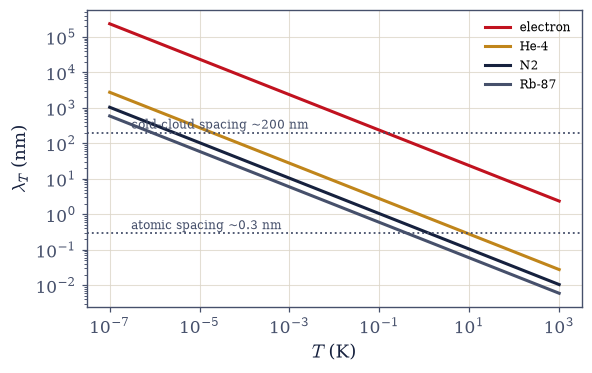

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.close(
    Z1_quad,
    Z1_closed,
    "Z_1 = V/λ_T^3: the DOS integral meets the Gaussian momentum integral",
    rtol=1e-8,
)
validate.check(
    lambda_T(M_ELECTRON, 300.0) > 100.0 * lambda_T(28.0134 * U_AMU, 300.0),
    "the 1/√m scaling: an electron's wavepacket dwarfs a nitrogen molecule's at the same T",
    f"ratio {lambda_T(M_ELECTRON, 300.0) / lambda_T(28.0134 * U_AMU, 300.0):.0f}×",
)

✓  Z_1 = V/λ_T^3: the DOS integral meets the Gaussian momentum integral   [got 0.108413 vs expected 0.108413 (rtol=1e-08)]
✓  the 1/√m scaling: an electron's wavepacket dwarfs a nitrogen molecule's at the same T   [ratio 226×]


True

## Exercise 2 — The degeneracy map

One dimensionless number, eleven decades of physics — the volume's road map in a single table.
Cite {eq}`eq-degeneracy-criterion`.

1. Implement `degeneracy(n, m, T)` $= n\lambda_T^3$ in SI with the CODATA constants stated in
   Setup.
2. Compute the table: air (300 K, 1 atm), Cu conduction electrons ($n = 8.5\times10^{28}$ m⁻³,
   300 K), liquid He-4 at $T_\lambda = 2.17$ K, ultracold Rb-87 ($n = 10^{20}$ m⁻³, 100 nK), Si
   intrinsic carriers ($10^{16}$ m⁻³, $m^* = 0.3m_e$, 300 K).
3. Confirm the verified values ($\sim1.6\times10^{-7}$; $6.8\times10^{3}$; $4.5$; $21$;
   $4.9\times10^{-9}$) and plot them on a log axis against the critical line
   $\zeta(3/2) = 2.612$.
4. Read the map (prose): metals are never classical (Movement III's mandate, next notebook);
   helium crosses the threshold where superfluidity in fact appears (honest interacting-system
   caveat); cold atoms engineer degeneracy ([§7.17](bose-einstein-condensation.ipynb)); semiconductor carriers are licensed Boltzmann
   ([§7.13](semiconductor-statistics.ipynb)).

In [6]:
# (solution hidden on the public site)


the degeneracy map, n λ_T^3:
  air, 300 K, 1 atm         1.61e-07
  Cu electrons, 300 K       6.77e+03
  liquid He-4 at T_lambda   4.53
  Rb-87 cloud, 100 nK       20.8
  Si carriers, 300 K        4.85e-09

the condensation threshold: ζ(3/2) = 2.6124   (the phase boundary of §7.17)


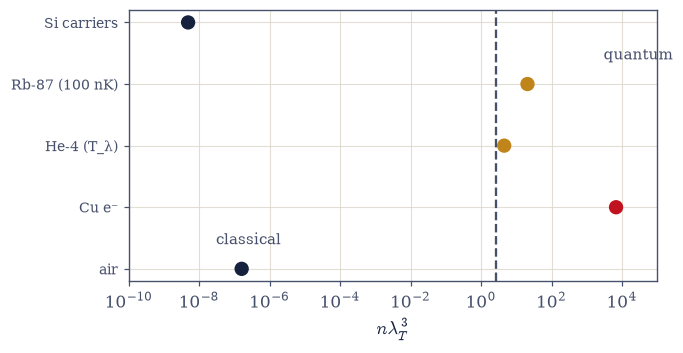

In [7]:
# (solution hidden on the public site)


### Validation 2

In [8]:
validate.close(
    deg_values,
    [1.6e-7, 6.8e3, 4.54, 20.7, 4.9e-9],
    "one number sorts matter: the five nλ³ values across eleven decades",
    rtol=8e-2,
)
validate.check(
    deg_values[0] < 1e-6 and deg_values[1] > 1e3 and 2.612 < deg_values[2] < 5.0,
    "the readings: air classical, copper never classical, helium just past the threshold",
)

✓  one number sorts matter: the five nλ³ values across eleven decades   [max|Δ| = 25.5052 (rtol=0.08, atol=1e-09)]
✓  the readings: air classical, copper never classical, helium just past the threshold


True

## Exercise 3 — The N! falls out

Volume V divided by $N!$ on faith; the occupation-number bookkeeping never needed the correction in the
first place. Cite {eq}`eq-gibbs-derived`.

1. Expand $\Xi = e^{zZ_1}$ in powers of $z$ and read off $Z_N = Z_1^N/N!$ by matching the
   definition $\Xi = \sum z^N Z_N$ (with a numerical partial-sum confirmation).
2. Explain (prose, carefully) *where* the $N!$ came from: occupation states never labelled
   particles, so the classical overcounting never occurred — the indistinguishability of [§6.20](../06-quantum-mechanics/identical-particles.ipynb) closing
   the account [§5.1](../05-classical-stat-mech/counting.ipynb)/[§5.6](../05-classical-stat-mech/ideal-gas-fundamental-relation.ipynb) opened.
3. Recap the Gibbs paradox in two sentences and verify its resolution numerically: compute the
   mixing entropy of two equal samples of the *same* ideal gas with and without the $N!$,
   confirming zero (extensive) versus $2Nk_B\ln2$ (paradox).
4. Complete the arc (prose): $h$ ([§7.5](oscillator-at-temperature.ipynb)), $\sigma$ ([§7.6](molecules-rotation-vibration.ipynb)), $N!$ (here) — each classical fudge
   factor a quantum limit; the volume's derivation arc complete.

In [9]:
# (solution hidden on the public site)


Σ (zZ_1)^N/N! (31 terms) = 2.225540928492468
e^(zZ_1)                 = 2.225540928492468

mixing two identical samples (per particle, units of k_B):
  with the N!  (v = V/N invariant):  ΔS = 0.000e+00
  without the N!:                    ΔS = 1.386294   (2 ln 2 = 1.386294)


### Validation 3

In [10]:
validate.close(
    partial,
    float(np.exp(zZ1)),
    "Ξ = e^(zZ_1) = Σ(zZ_1)^N/N!: the Gibbs factor read off the exponential series",
    rtol=1e-14,
)
validate.close(
    mix_with,
    0.0,
    "the Gibbs paradox dissolved: with the derived N!, mixing identical gases costs nothing",
    atol=1e-12,
)
validate.close(
    mix_without,
    2.0 * np.log(2.0),
    "without the N!: the spurious 2Nk_B ln 2 — the paradox Volume V had to divide away",
    rtol=1e-12,
)

✓  Ξ = e^(zZ_1) = Σ(zZ_1)^N/N!: the Gibbs factor read off the exponential series   [got 2.22554 vs expected 2.22554 (rtol=1e-14)]
✓  the Gibbs paradox dissolved: with the derived N!, mixing identical gases costs nothing   [got 0 vs expected 0 (rtol=1e-06)]
✓  without the N!: the spurious 2Nk_B ln 2 — the paradox Volume V had to divide away   [got 1.38629 vs expected 1.38629 (rtol=1e-12)]


True

## Exercise 4 — Sackur–Tetrode against the laboratory

A room-temperature calorimetric measurement that contains Planck's constant — the notebook's
jewel. Cite {eq}`eq-sackur-tetrode`.

1. Derive $S/Nk_B = \ln(v/\lambda_T^3) + \tfrac52$ from $Z_N = (V/\lambda^3)^N/N!$ via
   $F = -k_BT\ln Z$ and Stirling ([§5.3](../05-classical-stat-mech/large-n-limit.ipynb), invoked).
2. Implement `sackur_tetrode(m, T, P)` in SI and evaluate for argon at $298.15$ K, $1$ bar.
3. Confirm $154.85$ J mol⁻¹K⁻¹ against the measured standard molar entropy $154.85$ (stating the
   third-law calorimetric provenance of the measured value), matching every displayed digit.
4. Weigh the meaning (prose): classical thermodynamics can only ever measure entropy
   *differences*; the absolute value exists because phase space is cellular with cell size $h$ —
   $\hbar$, measured with a calorimeter, decades before quantum mechanics.

In [11]:
# (solution hidden on the public site)


Sackur–Tetrode, argon at 298.15 K, 1 bar:  S = 154.85 J/(mol K)
measured standard molar entropy:           S = 154.85 J/(mol K)
difference: 0.004 J/(mol K) — every displayed digit


### Validation 4

In [12]:
validate.close(
    S_argon,
    S_measured,
    "Sackur–Tetrode: the measured entropy of argon contains ℏ — matched to every displayed digit",
    rtol=1e-4,
)
validate.check(
    abs(S_argon - S_measured) < 0.02,
    "the match is at the second decimal, not merely the percent level",
    f"|Δ| = {abs(S_argon - S_measured):.4f} J/(mol K)",
)

✓  Sackur–Tetrode: the measured entropy of argon contains ℏ — matched to every displayed digit   [got 154.846 vs expected 154.85 (rtol=0.0001)]
✓  the match is at the second decimal, not merely the percent level   [|Δ| = 0.0043 J/(mol K)]


True

## Exercise 5 — The pure-statistics virial

With no forces anywhere, the two gases push differently on the walls — the first thermodynamic
whisper of exchange. Cite {eq}`eq-statistics-virial`.

1. Write the exact parametric EOS from the functions of [§7.3](statistical-toolkit.ipynb): $n\lambda^3 = \pm\mathrm{Li}_{3/2}(\pm z)$,
   $P\lambda^3/k_BT = \pm\mathrm{Li}_{5/2}(\pm z)$.
2. Implement `quantum_eos` with `mpmath.polylog` and extract the slope
   $(PV/Nk_BT - 1)/n\lambda^3$ at $z = 0.05$ and $0.02$ for both statistics.
3. Confirm convergence to $\mp1/2^{5/2} = \mp0.17678$, and show once how a larger $z$
   contaminates the fit with the $\mathcal{O}((n\lambda^3)^2)$ term.
4. Interpret (prose): a pressure deficit for bosons (statistical attraction — bunching's
   thermodynamic face, and the shadow of the condensation of [§7.17](bose-einstein-condensation.ipynb)) and a pressure excess for fermions
   (statistical repulsion — the embryo of the degeneracy pressure that opens [§7.9](fermi-gas-zero-temperature.ipynb)).

In [13]:
# (solution hidden on the public site)


target: ∓1/2^(5/2) = ∓0.17678
  bose : slope at z = 0.5: -0.17888   z = 0.05: -0.17694   z = 0.02: -0.17684
  fermi: slope at z = 0.5: +0.17538   z = 0.05: +0.17661   z = 0.02: +0.17671


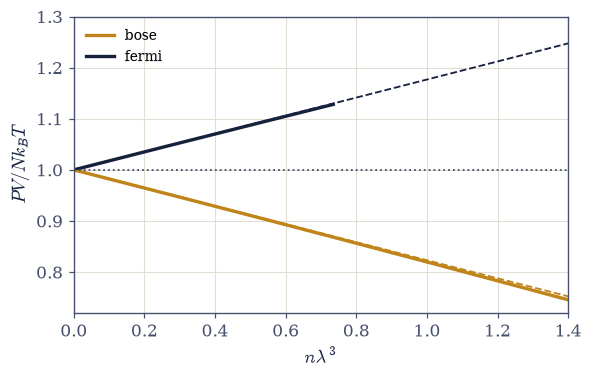

In [14]:
# (solution hidden on the public site)


### Validation 5

In [15]:
validate.close(
    virial_extracted,
    [-target, +target],
    "PV/Nk_BT = 1 ∓ nλ³/2^(5/2): the second virial coefficient of pure statistics",
    rtol=1e-2,
)
validate.check(
    abs(slopes[("bose", 0.02)] + target) < abs(slopes[("bose", 0.05)] + target)
    and abs(slopes[("bose", 0.05)] + target) < abs(slopes[("bose", 0.5)] + target),
    "the extraction converges as z → 0; the z = 0.5 fit is visibly contaminated by O((nλ³)²)",
    f"|error|: {abs(slopes[('bose', 0.5)] + target):.4f} → {abs(slopes[('bose', 0.05)] + target):.5f} → {abs(slopes[('bose', 0.02)] + target):.5f}",
)

✓  PV/Nk_BT = 1 ∓ nλ³/2^(5/2): the second virial coefficient of pure statistics   [max|Δ| = 6.65182e-05 (rtol=0.01, atol=1e-09)]
✓  the extraction converges as z → 0; the z = 0.5 fit is visibly contaminated by O((nλ³)²)   [|error|: 0.0021 → 0.00017 → 0.00007]


True

## Exercise 6 — The coherence length, exactly

The thermal wavepacket is not a metaphor: the one-body density matrix is a Gaussian of width
$\lambda_T$. Cite {eq}`eq-exchange-real-space`.

1. Write $\rho_1(r) = (1/V)\sum_k\langle n_k\rangle e^{i\mathbf{k}\cdot\mathbf{r}}$ and reduce
   the MB-limit sum to the radial integral $\propto \int dk\,k\sin(kr)\,e^{-\beta k^2/2}/r$.
2. Evaluate with `scipy.integrate.quad` ($r \to 0$ by its own limit integral, not by division)
   and normalize by $\rho_1(0)$.
3. Confirm $\rho_1(r)/n = e^{-\pi r^2/\lambda_T^2}$ to at least six digits at $r = 0.3, 0.8,
   1.5$ (working units).
4. Interpret (prose): $\lambda_T$ is the distance over which a thermal particle stays coherent
   with itself — the degeneracy criterion is literally "coherence volumes overlapping."

In [16]:
# (solution hidden on the public site)


λ_T = √(2πβ) = 2.506628  (working units)
  r = 0.3:  ρ_1/n (quad) = 0.955997482   Gaussian = 0.955997482
  r = 0.8:  ρ_1/n (quad) = 0.726149037   Gaussian = 0.726149037
  r = 1.5:  ρ_1/n (quad) = 0.324652467   Gaussian = 0.324652467


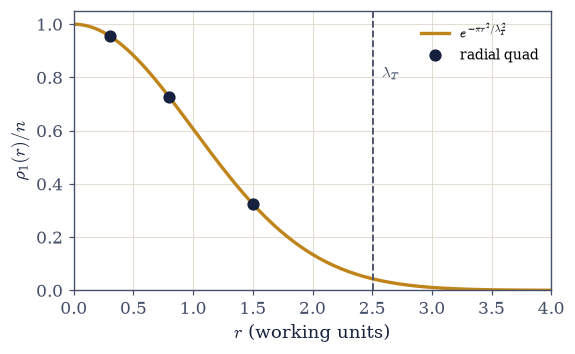

In [17]:
# (solution hidden on the public site)


### Validation 6

In [18]:
validate.close(
    rho1_num,
    rho1_gauss,
    "ρ_1 is a Gaussian of width λ_T: the coherence length, exact to six digits",
    rtol=1e-6,
)

✓  ρ_1 is a Gaussian of width λ_T: the coherence length, exact to six digits   [max|Δ| = 1.44329e-15 (rtol=1e-06, atol=1e-09)]


True

## Exercise 7 — Exchange in real space: the bunch and the hole

The pair correlation of an ideal gas at range $\lambda_T$ — certified by an exact two-particle
computation. Cite {eq}`eq-exchange-real-space`.

1. State and sketch the dilute-gas result $g(r) = 1 \pm |\rho_1(r)/n|^2 = 1 \pm e^{-2\pi
   r^2/\lambda_T^2}$, and plot both branches: the boson bunching peak $g(0) = 2$ and the fermion
   exchange hole $g(0) = 0$, each of range $\lambda_T$.
2. Certify the fermion side exactly: two thermal particles in a 1D box by explicit
   antisymmetrized pair sums over `numpy.arange` box modes (the $n = m$ diagonal *excluded*) —
   the coincidence amplitude is identically zero on the whole grid.
3. Certify the boson side honestly: the symmetrized computation ($n = m$ diagonal *included*,
   the `two_particle_R` helper) gives an integrated enhancement of $1.77$ at $N = 2$ in a
   $\lambda_T$-scale box, trending toward the ideal $2$ as the box grows — the finite-size
   sources stated.
4. Connect (prose): the $+e^{-2\pi r^2/\lambda^2}$ is the thermal bunching of [§7.5](oscillator-at-temperature.ipynb) and the $n(1+n)$ of [§7.7](bose-einstein-fermi-dirac.ipynb)
   landed in real space (Hanbury Brown–Twiss, named); the hole is Pauli in space, ancestor of
   the exchange–correlation holes of electronic-structure theory (a horizon nodding to [§7.12](bloch-theorem-band-structure.ipynb) and
   the MMM bridge).

In [19]:
# (solution hidden on the public site)


fermion coincidence amplitude, max over 1770 pairs × grid: 0.0

boson integrated enhancement R:  L = 10: 1.7668   L = 40: 1.9385   L = 160: 1.9844
(ideal thermodynamic-limit bunching factor: 2 — approached, not assumed)
grid-integrated ratio at L = 10: 1.766816   (helper closed form: 1.766816)


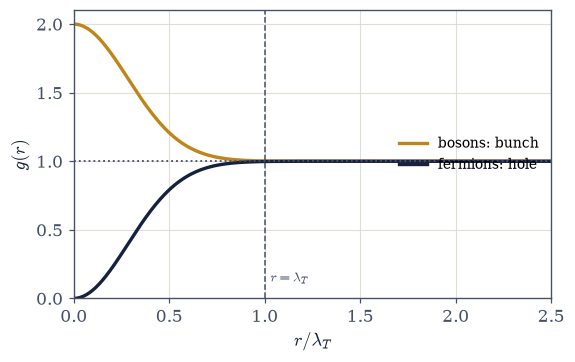

In [20]:
# (solution hidden on the public site)


### Validation 7

In [21]:
validate.close(
    coincidence_max,
    0.0,
    "the exchange hole is exact at any size: the antisymmetrized coincidence amplitude vanishes",
    atol=1e-15,
)
validate.close(
    R_10,
    1.77,
    "the boson enhancement in a small box: 1.77 at N = 2 — finite-size honest",
    rtol=2e-2,
)
validate.check(
    R_10 < R_40 < R_160 < 2.0 and R_160 > 1.95,
    "the enhancement trends to the ideal bunching factor 2 as the box grows",
    f"{R_10:.3f} → {R_40:.3f} → {R_160:.3f}",
)
validate.close(
    R_grid,
    R_10,
    "the literal grid integration confirms the pair-sum closed form (the diagonal bookkeeping)",
    rtol=1e-6,
)

✓  the exchange hole is exact at any size: the antisymmetrized coincidence amplitude vanishes   [got 0 vs expected 0 (rtol=1e-06)]
✓  the boson enhancement in a small box: 1.77 at N = 2 — finite-size honest   [got 1.76682 vs expected 1.77 (rtol=0.02)]
✓  the enhancement trends to the ideal bunching factor 2 as the box grows   [1.767 → 1.938 → 1.984]
✓  the literal grid integration confirms the pair-sum closed form (the diagonal bookkeeping)   [got 1.76682 vs expected 1.76682 (rtol=1e-06)]


True

## Exercise 8 — Movement II, closed — and the map unfolded

Two notebooks ago the volume derived its two distributions; this one drew the boundary of the
country where they may be ignored, and found the border crossings marked. The classical world is
where wavepackets never touch: too dilute, too heavy, too warm. Inside it, quantum mechanics
still left three signatures no classical theory could forge — an absolute entropy that a
calorimeter can read and only $\hbar$ can explain, a factorial that Volume V posited and
indistinguishability explained, and a pressure that already leans boson-soft or fermion-stiff before
any force is switched on. Outside it, three roads: dense and light to the metals and the dead
stars (Movement III begins at once), cold to the condensates (Movement IV), and massless to the
light that never was classical ([§7.14](photon-gas-planck.ipynb)).

There is a pleasing finality to the $N!$ story. Classical statistical mechanics was right for a
century while carrying three unexplained factors in its books ($h$, $\sigma$, $N!$), like a
merchant whose accounts balance only with entries he cannot justify. The audit took one idea:
particles do not have names. Every entry cleared.

The volume now follows the first road. Next door ([§7.9](fermi-gas-zero-temperature.ipynb)): the Fermi sea at absolute zero, where the
statistical repulsion of this notebook's virial grows up into the degeneracy pressure that
structures metals — and, three notebooks later, holds up the corpses of stars.

## Notebook summary

Movement II closes by locating the classical world and auditing what quantum mechanics left
inside it.

- **The thermal wavelength** {eq}`eq-thermal-wavelength`: both gases collapse onto $\ln\Xi = zZ_1$
  with $Z_1 = V/\lambda_T^3$, $\lambda_T = h/\sqrt{2\pi mk_BT}$ — the Gaussian momentum integral
  against the DOS integral to eight digits, and $1/\sqrt{mT}$: light and cold is quantum.
- **The degeneracy map** {eq}`eq-degeneracy-criterion`: $n\lambda_T^3$ in honest SI sorts air
  ($10^{-7}$), copper's electrons ($7\times10^3$ — never classical: Movement III's mandate),
  helium at $T_\lambda$ ($4.5$, just past $\zeta(3/2)$ — superfluid on schedule,
  semiquantitatively), an engineered Rb cloud ($21$), and silicon's carriers ($5\times10^{-9}$ —
  the Boltzmann license of [§7.13](semiconductor-statistics.ipynb)) across eleven decades.
- **The N! derived** {eq}`eq-gibbs-derived`: $\Xi = e^{zZ_1}$ hands over $Z_N = Z_1^N/N!$ — the
  factorial derived, because occupation states never labelled particles; the Gibbs paradox
  dissolves numerically ($0$ with, $2Nk_B\ln2$ without). The arc closes: $h$ ([§7.5](oscillator-at-temperature.ipynb)), $\sigma$
  ([§7.6](molecules-rotation-vibration.ipynb)), $N!$ (here).
- **Sackur–Tetrode** {eq}`eq-sackur-tetrode`: argon's computed $154.85$ J mol⁻¹K⁻¹ meets the
  third-law calorimetric $154.85$ at the second decimal — a room-temperature measurement that
  contains Planck's constant, and the notebook's jewel.
- **The pure-statistics virial** {eq}`eq-statistics-virial`: $PV/Nk_BT = 1 \mp n\lambda^3/2^{5/2}$
  extracted from the exact polylogarithm EOS, converging to $\mp0.17678$ (with the large-$z$
  contamination shown once) — attraction without a force for bosons, repulsion for fermions: the
  embryo of degeneracy pressure.
- **Exchange in real space** {eq}`eq-exchange-real-space`: $\rho_1(r)/n = e^{-\pi r^2/\lambda_T^2}$
  to six digits ($\lambda_T$ *is* the coherence length), so $g(r) = 1 \pm e^{-2\pi r^2/\lambda_T^2}$:
  the bunching peak $g(0) = 2$ (HBT's factor of two) and the exchange hole $g(0) = 0$ — the hole
  certified identically by the antisymmetrized box computation (no thermodynamic limit needed),
  the bunching honestly ($1.77$ at $N = 2$, trending to $2$).

One length decided everything; the movements now leave the classical country by its three exits.

## Outlook

- **The Fermi sea at $T = 0$ ([§7.9](fermi-gas-zero-temperature.ipynb)).** Degeneracy pressure as the fermionic virial's grown-up
  form — Movement III opens.
- **The structured-matter arc.** Metals and Sommerfeld ([§7.10](fermi-gas-finite-temperature.ipynb)); the stellar summit ([§7.11](white-dwarfs-chandrasekhar.ipynb)); Bloch
  and the banded DOS ([§7.12](bloch-theorem-band-structure.ipynb)); carriers licensed Boltzmann by this notebook's criterion ([§7.13](semiconductor-statistics.ipynb)).
- **The other exits.** $n\lambda^3 = \zeta(3/2)$ as a phase boundary — condensation ([§7.17](bose-einstein-condensation.ipynb));
  $\mu = 0$ light ([§7.14](photon-gas-planck.ipynb)).
- **The ring polymer's size is $\lambda_T$** — the path-integral picture of this notebook's
  coherence length ([§7.20](imaginary-time-quantum-classical.ipynb)/[§7.21](path-integral-monte-carlo.ipynb), named).
- **Cross-reference** [§5.1](../05-classical-stat-mech/counting.ipynb)/[§5.3](../05-classical-stat-mech/large-n-limit.ipynb)/[§5.6](../05-classical-stat-mech/ideal-gas-fundamental-relation.ipynb) (the accounts, closed), [§6.20](../06-quantum-mechanics/identical-particles.ipynb) (the idea that closed them), [§7.3](statistical-toolkit.ipynb)
  (the functions), [§7.5](oscillator-at-temperature.ipynb)/[§7.6](molecules-rotation-vibration.ipynb) (the arc's first two entries), [§7.7](bose-einstein-fermi-dirac.ipynb) (the distributions and their
  ordering).

In [22]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>